# Dependency package

In [1]:
import os
import time
import numpy as np

import mne
from mne.channels import make_standard_montage
# from mne.decoding import CSP

import sklearn
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import KFold , train_test_split , GridSearchCV
from sklearn.ensemble import VotingClassifier

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

import scipy
from scipy import stats
from scipy.io import loadmat
from scipy.signal import welch

from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns

import pyriemann
from pyriemann.clustering import Kmeans as pyKmeans

print(f"numpy version: {np.__version__}")
print(f"mne version: {mne.__version__}")
print(f"sklearn version: {sklearn.__version__}")
print(f"scipy version: {scipy.__version__}")
print(f"pyriemann version: {pyriemann.__version__}")
start_time = time.time()

numpy version: 2.2.6
mne version: 1.10.1
sklearn version: 1.7.2
scipy version: 1.15.3
pyriemann version: 0.10


# Dataset Setting

In [2]:
def Dataset_Setter(Dataset_Selection:int=0):
    # Select dataset
    # 0: BCICIV_2a
    # 1: BCICIV_2b
    # 2: BCICIV_1
    # Dataset_Selection

    # dataset format
    # 0: gdf
    # 1: mat
    # dataFormat
    match Dataset_Selection:
        case 0:
            dataFormat = 0
            dirPath = f'../../dataset/BCICIV_2a_gdf/' # GDF read dir path
            participants = [] # EEG-MI 受試者
            participantsNum = 9 # EEG-MI 受試者人數
            for i in range(1,participantsNum+1,1):
                participants = participants + [f'A0{i}T']  # bci4_2A
            filenamePrefix = ""
            filenamePostfix = '.gdf'
            target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
            # BCI4 2A 資料集電擊轉換成標準10-20系統
            channel_rename_map = {
                'EEG-Fz' : 'Fz'  ,
                'EEG-0'  : 'FC3' ,
                'EEG-1'  : 'FC1' ,
                'EEG-2'  : 'FCz' ,
                'EEG-3'  : 'FC2' ,
                'EEG-4'  : 'FC4' ,
                'EEG-5'  : 'C5'  ,
                'EEG-C3' : 'C3'  ,
                'EEG-6'  : 'C1'  ,
                'EEG-Cz' : 'Cz'  ,
                'EEG-7'  : 'C2'  ,
                'EEG-C4' : 'C4'  ,
                'EEG-8'  : 'C6'  ,
                'EEG-9'  : 'CP3' ,
                'EEG-10' : 'CP1' ,
                'EEG-11' : 'CPz' ,
                'EEG-12' : 'CP2' ,
                'EEG-13' : 'CP4' ,
                'EEG-14' : 'P1'  ,
                'EEG-Pz' : 'Pz'  ,
                'EEG-15' : 'P2'  ,
                'EEG-16' : 'POz' ,
                'EOG-left'   : 'EOG-left',
                'EOG-central': 'EOG-central',
                'EOG-right'  : 'EOG-right'
            }
            channel_types = {
                'EEG-Fz' : 'eeg',
                'EEG-0'  : 'eeg',
                'EEG-1'  : 'eeg',
                'EEG-2'  : 'eeg',
                'EEG-3'  : 'eeg',
                'EEG-4'  : 'eeg',
                'EEG-5'  : 'eeg',
                'EEG-C3' : 'eeg',
                'EEG-6'  : 'eeg',
                'EEG-Cz' : 'eeg',
                'EEG-7'  : 'eeg',
                'EEG-C4' : 'eeg',
                'EEG-8'  : 'eeg',
                'EEG-9'  : 'eeg',
                'EEG-10' : 'eeg',
                'EEG-11' : 'eeg',
                'EEG-12' : 'eeg',
                'EEG-13' : 'eeg',
                'EEG-14' : 'eeg',
                'EEG-Pz' : 'eeg',
                'EEG-15' : 'eeg',
                'EEG-16' : 'eeg',
                'EOG-left'   : 'eog',
                'EOG-central': 'eog',
                'EOG-right'  : 'eog'
            }
            downsamplingFreq = None
        case 1:
            dataFormat = 0
            dirPath = f'../../dataset/BCICIV_2b_gdf/'
            participants = []
            participantsNum = 9
            participantsId = ['B0103T','B0203T','B0303T','B0403T','B0503T','B0603T','B0703T','B0803T','B0903T']
            filenamePrefix = ''
            filenamePostfix = '.gdf'
            for i in participantsId:
                participants = participants + [i]  # bci4_2B
            target_keys = ['769', '770'] # 任務Code, 769 左手, 770右手
            # BCI4 2B 資料集電擊轉換成標準10-20系統
            channel_rename_map = {
                'EEG:C3' : 'C3'  ,
                'EEG:Cz' : 'Cz'  ,
                'EEG:C4' : 'C4'  ,
                'EOG:ch01':'EOG:ch01',
                'EOG:ch02':'EOG:ch02',
                'EOG:ch03':'EOG:ch03'
            }
            channel_types = {
                'EEG:C3'   : 'eeg',
                'EEG:Cz'   : 'eeg',
                'EEG:C4'   : 'eeg',
                'EOG:ch01' : 'eog',
                'EOG:ch02' : 'eog',
                'EOG:ch03' : 'eog'
            }
            downsamplingFreq = None
        case 2:
            dataFormat = 1
            dirPath = f'../../dataset/BCICIV_1calib_1000Hz_mat/'
            participants = []
            participantsNum = 3
            participantsId = ['ds1b','ds1c','ds1g']
            filenamePrefix = 'BCICIV_calib_'
            filenamePostfix = '_1000Hz.mat'
            for i in participantsId:
                participants = participants + [i]  # bci4_1
            target_keys = ['Left', 'Right'] # 任務
            # BCI4 2B 資料集電擊轉換成標準10-20系統
            channel_rename_map = None
            channel_types = None
            downsamplingFreq = 250

    saveResultPath = './results/' # 結果儲存資料夾
    try:
        os.mkdir(saveResultPath) # 創建結果儲存資料夾
        os.mkdir(saveResultPath +'./confuseMatrix/') # 創建結果儲存資料夾
        print(f"Create Result Dir Successful.")
    except:
        pass

    return {
        'dataFormat': dataFormat,
        'dirPath': dirPath,
        'participants': participants,
        'filenamePrefix': filenamePrefix,
        'filenamePostfix': filenamePostfix,
        'target_keys': target_keys,
        'channel_rename_map': channel_rename_map,
        'channel_types': channel_types,
        'downsamplingFreq': downsamplingFreq,
        'saveResultPath': saveResultPath,
        }

# Pre-Processing Setting

In [3]:
def Preprocessing_Setter():
    # band pass filter
    fs = 250
    lowcut = 8
    highcut = 30
    filter_order = 8
    filter_type = 'butter' # Butterworth
    iir_params = dict(order=filter_order, ftype=filter_type)

    # 擷取實驗時間，0秒是cued開始
    # C: number of channels
    # P: number of temporal points
    # N: number of trials
    # (tmax-tmin)*250+1=500
    # tmax = (P-1)/fs+tmin
    time_interval = 3.5
    P = time_interval*fs
    tmin = 0.5
    tmax = (P-1)/fs+tmin
    print(f"Time from {tmin} s to {tmax} s, sample point: {P}")

    # CSP M值
    M = 3

    return {
        'lowcut': lowcut,
        'highcut': highcut,
        'iir_params': iir_params,
        'tmin': tmin,
        'tmax': tmax,
    }

# Data Epoch

In [4]:
def Dataset_Epocher(Dataset_Selection_List:list=[0]):
    # Dataset_Selection_List
    # 0: BCICIV_2a
    # 1: BCICIV_2b
    # 2: BCICIV_1
    epochs = {}
    PreprocessingConfig = Preprocessing_Setter()
    for Dataset_Selection in Dataset_Selection_List:
        DatasetConfig = Dataset_Setter(Dataset_Selection=Dataset_Selection)
        montage = make_standard_montage('standard_1020')
        if DatasetConfig['channel_rename_map']:
            eeg_only_channels = [
                name
                for name in DatasetConfig['channel_rename_map'].values()
                if not name.startswith('EOG')
            ]
        else:
            eeg_only_channels = None

        for subject in DatasetConfig['participants']:
            filePath = DatasetConfig['dirPath'] + f"./{DatasetConfig['filenamePrefix']}{subject}{DatasetConfig['filenamePostfix']}"
            match DatasetConfig['dataFormat']:
                case 0:
                    try:
                        raw = mne.io.read_raw_gdf(filePath, preload=True, verbose="ERROR")
                    except Exception as e:
                        print(f"讀取 GDF 檔案時發生錯誤: {e}")
                        raise
                case 1:
                    try:
                        mat_data = loadmat(filePath, struct_as_record=False, squeeze_me=True)
                        eeg_data = mat_data['cnt']     # 這是訊號矩陣 (Time x Channels)
                        sfreq = mat_data['nfo'].fs     # 採樣率
                        ch_names = mat_data['nfo'].clab # 通道名稱
                        classes = mat_data['nfo'].classes
                        events_sample = mat_data['mrk'].pos - 1
                        events_id = np.where(mat_data['mrk'].y == -1, 1, 2)
                        info = mne.create_info(ch_names=list(ch_names), sfreq=sfreq, ch_types='eeg', verbose='Error')
                        raw = mne.io.RawArray(eeg_data.T * 1e-6, info, verbose='Error')
                        events = np.column_stack((
                            events_sample,
                            np.zeros_like(events_sample, dtype=int),
                            events_id.astype(int)
                        ))
                        mapping = {1: 'Left', 2: 'Right'}
                        annot = mne.annotations_from_events(
                            events=events,
                            sfreq=raw.info['sfreq'],
                            event_desc=mapping
                        )
                        raw.set_annotations(annot)
                    except Exception as e:
                        print(f"讀取 GDF 檔案時發生錯誤: {e}")
                        raise
            ## Raw setting
            if DatasetConfig['channel_types']:
                raw.set_channel_types(DatasetConfig['channel_types'], verbose="ERROR") # 設定電擊種類是EEG還是EOG
            if DatasetConfig['channel_rename_map']:
                raw.rename_channels(DatasetConfig['channel_rename_map'], verbose="ERROR") # 重新命名電擊名稱符合10-20系統
            if DatasetConfig['downsamplingFreq']:
                raw.resample(sfreq=DatasetConfig['downsamplingFreq']) # downsampling
            raw.set_eeg_reference([], verbose="ERROR") # 設定reference電擊
            raw.set_montage(montage, on_missing='ignore', verbose="ERROR") # 設定10-20系統

            ## Regression
            # model = mne.preprocessing.EOGRegression(picks='eeg', picks_artifact='eog')
            # model.fit(raw)
            # raw = model.apply(raw)
            if eeg_only_channels:
                raw.pick_channels(eeg_only_channels, verbose="ERROR") # Remove EOG data
            raw.filter( # Bandpass filter
                l_freq=PreprocessingConfig['lowcut'],
                h_freq=PreprocessingConfig['highcut'],
                method='iir',
                iir_params=PreprocessingConfig['iir_params'],
                verbose="ERROR"
            )
            ## 選取事件做成epoch
            events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
            kept_event_ids = {
                key: value
                for key, value in event_id.items()
                if key in DatasetConfig['target_keys']
            }
            events_of_interest = events[np.isin(events[:, 2], list(kept_event_ids.values()))]
            new_id_mapping = {old_id: i for i, old_id in enumerate(kept_event_ids.values())}
            kept_event_ids = {key: i for i, key in enumerate(kept_event_ids.keys())}
            for i in range(len(events_of_interest)):
                old_val = events_of_interest[i, 2]
                events_of_interest[i, 2] = new_id_mapping[old_val]
            baseline = None # 不做基線校正，或您可以定義 (-0.5, 0)
            epoch = mne.Epochs(
                raw,
                events_of_interest,
                event_id=kept_event_ids,
                tmin=PreprocessingConfig['tmin'],
                tmax=PreprocessingConfig['tmax'],
                baseline=baseline,
                preload=True,        # 將數據載入內存
                proj=False,           # 暫時不應用投影
                verbose="ERROR"
            )
            epochs[subject] = epoch
            print(f"{subject} epoch create successful")

    return epochs

In [5]:
Dataset_Selection_List = [0,1,2]
epochs = Dataset_Epocher(Dataset_Selection_List=Dataset_Selection_List)

Time from 0.5 s to 3.996 s, sample point: 875.0
A01T epoch create successful
A02T epoch create successful
A03T epoch create successful
A04T epoch create successful
A05T epoch create successful
A06T epoch create successful
A07T epoch create successful
A08T epoch create successful
A09T epoch create successful
B0103T epoch create successful
B0203T epoch create successful
B0303T epoch create successful
B0403T epoch create successful
B0503T epoch create successful
B0603T epoch create successful
B0703T epoch create successful
B0803T epoch create successful
B0903T epoch create successful
ds1b epoch create successful
ds1c epoch create successful
ds1g epoch create successful


# Pick channel

In [17]:
def pick_channel(epochs):
    pick_channel = None
    pick_channel_Num = 1e6
    for subject in epochs.keys():
        if len(epochs[subject].ch_names) < pick_channel_Num:
            pick_channel = epochs[subject].ch_names
            pick_channel_Num = len(epochs[subject].ch_names)
    for subject in epochs.keys():
        epochs[subject].pick(pick_channel)
    return epochs

In [18]:
epochs = pick_channel(epochs=epochs)

In [19]:
for subject in epochs.keys():
    print(f"{subject}: {epochs[subject].ch_names}")

A01T: ['C3', 'Cz', 'C4']
A02T: ['C3', 'Cz', 'C4']
A03T: ['C3', 'Cz', 'C4']
A04T: ['C3', 'Cz', 'C4']
A05T: ['C3', 'Cz', 'C4']
A06T: ['C3', 'Cz', 'C4']
A07T: ['C3', 'Cz', 'C4']
A08T: ['C3', 'Cz', 'C4']
A09T: ['C3', 'Cz', 'C4']
B0103T: ['C3', 'Cz', 'C4']
B0203T: ['C3', 'Cz', 'C4']
B0303T: ['C3', 'Cz', 'C4']
B0403T: ['C3', 'Cz', 'C4']
B0503T: ['C3', 'Cz', 'C4']
B0603T: ['C3', 'Cz', 'C4']
B0703T: ['C3', 'Cz', 'C4']
B0803T: ['C3', 'Cz', 'C4']
B0903T: ['C3', 'Cz', 'C4']
ds1b: ['C3', 'Cz', 'C4']
ds1c: ['C3', 'Cz', 'C4']
ds1g: ['C3', 'Cz', 'C4']


In [ ]:
import numpy as np
import mne
from pyriemann.estimation import Covariances
from pyriemann.clustering import Kmeans
from pyriemann.utils.mean import mean_riemann
from pyriemann.utils.distance import distance
from pyriemann.spatialfilters import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# 假設 epochs_dict 已經載入
# epochs_dict = {'A01T': epoch1, ...}
epochs_dict = epochs
subject_keys = list(epochs_dict.keys())

# --- Step 1. 統一規格與參數設定 ---
target_sfreq = 250.0
n_clusters = 2
# 找出共同通道
common_channels = sorted(list(set.intersection(*[set(epochs_dict[k].ch_names) for k in subject_keys])))
print(f"使用 {len(common_channels)} 個共同通道進行分析。")

# --- Step 2. 預計算 Covariance 與 黎曼均值 (加速運算) ---
print("\n[階段一] 提取協方差矩陣與受試者黎曼均值...")
cov_estimator = Covariances(estimator='lwf')
covs_dict = {}
y_dict = {}
mean_covs_dict = {}

for sub in subject_keys:
    # 複製、挑選通道、重採樣
    epochs = epochs_dict[sub].copy().pick_channels(common_channels).resample(target_sfreq)

    X = epochs.get_data()          # shape: (n_trials, n_channels, n_times)
    y = epochs.events[:, -1]       # 取得 Label (假設符合 MNE events 格式)

    # 算出這個受試者所有 Trial 的 Covariance 矩陣
    covs = cov_estimator.fit_transform(X) # shape: (n_trials, n_channels, n_channels)

    covs_dict[sub] = covs
    y_dict[sub] = y
    mean_covs_dict[sub] = mean_riemann(covs) # 計算代表該受試者的黎曼中心

# --- Step 3. 執行 LOOCV (Leave-One-Subject-Out) ---
print("\n[階段二] 開始執行 LOOCV 交叉驗證...")
cv_scores = {}

for test_sub in subject_keys:
    # 劃分 Train / Test
    train_subs = [s for s in subject_keys if s != test_sub]

    # ------------------------------------------------
    # [訓練階段]
    # ------------------------------------------------
    # 1. 對訓練集的受試者進行 Riemann K-Means 分群
    train_means = np.array([mean_covs_dict[s] for s in train_subs])
    rkmeans = Kmeans(n_clusters=n_clusters, metric='riemann')
    rkmeans.fit(train_means)

    # 取得分群標籤與群組中心 (加入 try-except 避免版本相容性問題)
    train_labels = rkmeans.labels_
    try:
        cluster_centroids = rkmeans.centroids()
    except TypeError:
        cluster_centroids = rkmeans.centroids

    # 2. 針對每個 Cluster 訓練專屬的 CSP + LDA
    pipelines = {}
    for k in range(n_clusters):
        # 找出屬於第 k 群的受試者名單
        subs_in_k = [train_subs[i] for i in range(len(train_subs)) if train_labels[i] == k]

        if len(subs_in_k) == 0: continue # 避免空群集

        # 將該群受試者的所有 Trial 數據與 Label 合併
        X_train_k = np.concatenate([covs_dict[s] for s in subs_in_k])
        y_train_k = np.concatenate([y_dict[s] for s in subs_in_k])

        # 建立並訓練 Pipeline：CSP (提取 4 個空間濾波特徵) -> LDA (分類)
        # 備註：pyriemann 的 CSP 是直接吃 Covariance 矩陣的！
        clf = make_pipeline(CSP(nfilter=4, metric='riemann'), LinearDiscriminantAnalysis())
        clf.fit(X_train_k, y_train_k)

        pipelines[k] = clf # 儲存該群的模型

    # ------------------------------------------------
    # [測試階段] (Zero-calibration: 針對每個 Trial 獨立匹配)
    # ------------------------------------------------
    test_covs = covs_dict[test_sub]
    test_y = y_dict[test_sub]
    y_pred = []

    # 逐一 Trial 進行預測 (完美符合 Single Trial 零校準邏輯)
    for cov in test_covs:
        # 1. 尋找這個 Trial 的 Cov 離哪個群組的中心最近
        dists = [distance(cov, centroid, metric='riemann') for centroid in cluster_centroids]
        best_k = np.argmin(dists)

        # 2. 丟入該群組專屬的 CSP+LDA 進行預測
        # predict 需要 3D array，所以用 np.newaxis 增加一個維度 (1, n_channels, n_channels)
        pred = pipelines[best_k].predict(cov[np.newaxis, :, :])[0]
        y_pred.append(pred)

    # 計算該受試者的最終準確率
    acc = accuracy_score(test_y, y_pred)
    cv_scores[test_sub] = acc
    print(f"受試者 {test_sub:^8} | 準確率: {acc*100:.2f}%")

# --- Step 4. 輸出最終平均結果 ---
mean_acc = np.mean(list(cv_scores.values()))
print("="*35)
print(f"LOOCV 平均準確率: {mean_acc*100:.2f}%")

使用 3 個共同通道進行分析。

[階段一] 提取協方差矩陣與受試者黎曼均值...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Sampling frequency of the instance is already 250.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Sampling frequency of the instance is already 250.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Sampling frequency of the instance is already 250.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Sampling frequency of the instance is already 250.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Sampling frequency of the instance is already 250.0, returning unmodified.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Sampling frequency of the instance is already 250.0, returning unmodified.
NOTE: pick_channels() is a l

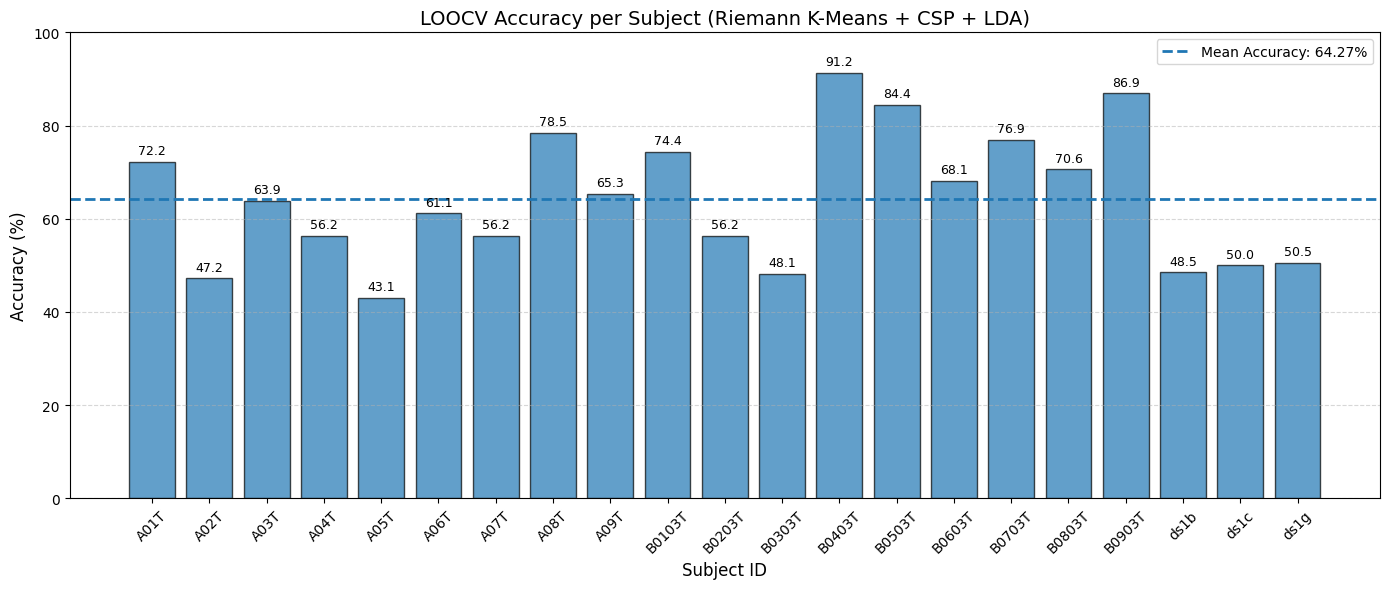

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 確保 cv_scores 已經計算完畢
subjects = list(cv_scores.keys())
# 將小數點準確率轉換為百分比 (%)
scores = [cv_scores[sub] * 100 for sub in subjects]
mean_score = np.mean(scores)

# 設定畫布大小
plt.figure(figsize=(14, 6))

# 繪製長條圖
bars = plt.bar(subjects, scores, alpha=0.7, edgecolor='black')

# 繪製平均準確率的水平虛線
plt.axhline(y=mean_score, linestyle='--', linewidth=2,
            label=f'Mean Accuracy: {mean_score:.2f}%')

# 加上數值標籤 (在每個長條的頂端顯示精確數字)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1,
             f'{yval:.1f}', ha='center', va='bottom', fontsize=9)

# 設定圖表標籤與標題
plt.xlabel('Subject ID', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('LOOCV Accuracy per Subject (Riemann K-Means + CSP + LDA)', fontsize=14)
plt.ylim(0, 100) # Y軸範圍設為 0~100%
plt.xticks(rotation=45) # 旋轉 X 軸標籤以免文字重疊
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 顯示圖表
plt.tight_layout()
plt.show()

# Data Splitting

In [5]:
trainData = {}
testData = {}
WholeData = {}
seed = 42
for subject in participants:
    X = epochs[subject].get_data() # trials,chs,samples
    X = X - np.mean(X, axis=-1, keepdims=True)
    y = epochs[subject].events[:, 2]

    # X_train, X_test, y_train, y_test = train_test_split(
    # X, y, test_size=0.2, shuffle=False)

    # trainData[subject] = {
    #     'Data': X_train,
    #     'Label': y_train
    # }

    # testData[subject] = {
    #     'Data': X_test,
    #     'Label': y_test
    # }

    WholeData[subject] = {
        'Data': X,
        'Label': y
    }


# Claude Reimann K means

In [6]:
results = {}
for subject in participants:
    X_train = WholeData[subject]['Data']
    y_train = WholeData[subject]['Label']
    """
    BCI Competition IV-2a: Riemannian K-Means Feature Extraction + LDA Classification
    純 NumPy 實作 Riemannian geometry，sklearn 只用於 LDA
    """

    import numpy as np
    from scipy.io import loadmat
    from scipy.signal import butter, filtfilt
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    from sklearn.model_selection import cross_val_score, StratifiedKFold
    from sklearn.preprocessing import LabelEncoder
    import warnings
    warnings.filterwarnings('ignore')

    # ─────────────────────────────────────────────────────────────
    # 2. SPD COVARIANCE MATRICES
    # ─────────────────────────────────────────────────────────────

    def compute_covariance(X: np.ndarray, regularize: float = 1e-6) -> np.ndarray:
        """
        計算每個 trial 的正規化協方差矩陣（SPD matrix）。

        使用公式：Σ = (X_c @ X_c.T) / (T - 1)
        再加 Tikhonov 正規化確保嚴格正定。

        X:      (n_trials, n_channels, n_times)
        return: (n_trials, n_channels, n_channels)
        """
        n_trials, n_ch, n_t = X.shape
        C = np.zeros((n_trials, n_ch, n_ch))

        for i in range(n_trials):
            Xi = X[i] - X[i].mean(axis=1, keepdims=True)   # zero-mean
            Ci = (Xi @ Xi.T) / (n_t - 1)
            C[i] = Ci + regularize * np.eye(n_ch)

        return C


    # ─────────────────────────────────────────────────────────────
    # 3. RIEMANNIAN GEOMETRY  (純 NumPy)
    # ─────────────────────────────────────────────────────────────

    def _eigh_safe(A: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """eigen-decomposition，eigenvalue clip 確保正定"""
        vals, vecs = np.linalg.eigh(A)
        vals = np.maximum(vals, 1e-12)
        return vals, vecs


    def matrix_sqrt(A: np.ndarray) -> np.ndarray:
        """A^{1/2}"""
        v, Q = _eigh_safe(A)
        return Q @ np.diag(np.sqrt(v)) @ Q.T


    def matrix_sqrt_inv(A: np.ndarray) -> np.ndarray:
        """A^{-1/2}"""
        v, Q = _eigh_safe(A)
        return Q @ np.diag(1.0 / np.sqrt(v)) @ Q.T


    def matrix_log(A: np.ndarray) -> np.ndarray:
        """對稱正定矩陣的對數 log(A)"""
        v, Q = _eigh_safe(A)
        return Q @ np.diag(np.log(v)) @ Q.T


    def matrix_exp(A: np.ndarray) -> np.ndarray:
        """對稱矩陣的指數 exp(A)"""
        v, Q = np.linalg.eigh(A)          # exp 不需要 clip
        return Q @ np.diag(np.exp(v)) @ Q.T


    def riemannian_distance(A: np.ndarray, B: np.ndarray) -> float:
        """
        Affine-invariant Riemannian distance：
            d(A, B) = || log( A^{-1/2} B A^{-1/2} ) ||_F
        """
        A_invsqrt = matrix_sqrt_inv(A)
        M = A_invsqrt @ B @ A_invsqrt
        logM = matrix_log(M)
        return float(np.sqrt(np.sum(logM ** 2)))


    def riemannian_mean(
        C: np.ndarray,
        max_iter: int = 50,
        tol: float = 1e-7
    ) -> np.ndarray:
        """
        Fréchet (Karcher) mean on the SPD manifold。

        迭代公式：
            S   = (1/N) Σ log( M^{-1/2} C_i M^{-1/2} )
            M   ← M^{1/2} exp(S) M^{1/2}

        收斂條件：||M_new - M||_F / ||M||_F < tol
        """
        n = len(C)
        M = C.mean(axis=0)                  # Euclidean mean 作初始值

        for _ in range(max_iter):
            M_sqrt    = matrix_sqrt(M)
            M_invsqrt = matrix_sqrt_inv(M)

            S = np.zeros_like(M)
            for i in range(n):
                inner = M_invsqrt @ C[i] @ M_invsqrt
                S += matrix_log(inner)
            S /= n

            M_new = M_sqrt @ matrix_exp(S) @ M_sqrt
            delta = np.linalg.norm(M_new - M, 'fro') / (np.linalg.norm(M, 'fro') + 1e-12)
            M = M_new
            if delta < tol:
                break

        return M


    # ─────────────────────────────────────────────────────────────
    # 4. RIEMANNIAN K-MEANS
    # ─────────────────────────────────────────────────────────────

    def riemannian_kmeans(
        C: np.ndarray,
        n_clusters: int = 8,
        max_iter: int = 30,
        n_init: int = 3,
        seed: int = 42
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        K-Means on SPD manifold。

        初始化：K-Means++ on Riemannian distance
        M-step：每個 cluster 取 Riemannian mean (Karcher flow)
        E-step：每個點分配到最近的 centroid

        Returns
        -------
        centroids : (K, p, p)
        labels    : (n_trials,)
        """
        rng = np.random.default_rng(seed)
        n   = len(C)
        best_inertia   = np.inf
        best_centroids = None
        best_labels    = None

        for run in range(n_init):
            # ── K-Means++ init ────────────────────────────────────
            idx = [int(rng.integers(n))]
            for _ in range(1, n_clusters):
                dists_sq = np.array([
                    min(riemannian_distance(C[i], C[j]) for j in idx) ** 2
                    for i in range(n)
                ])
                probs = dists_sq / dists_sq.sum()
                idx.append(int(rng.choice(n, p=probs)))
            centroids = C[np.array(idx)].copy()

            labels = np.zeros(n, dtype=int)
            for it in range(max_iter):

                # ── E-step ────────────────────────────────────────
                dist_mat   = np.array([
                    [riemannian_distance(C[i], centroids[k]) for k in range(n_clusters)]
                    for i in range(n)
                ])
                new_labels = dist_mat.argmin(axis=1)

                converged = np.all(new_labels == labels) and it > 0
                labels    = new_labels

                # ── M-step ────────────────────────────────────────
                new_centroids = centroids.copy()
                for k in range(n_clusters):
                    members = C[labels == k]
                    if len(members) == 1:
                        new_centroids[k] = members[0]
                    elif len(members) > 1:
                        new_centroids[k] = riemannian_mean(members)
                    # len==0: centroid 保持不變（空 cluster）
                centroids = new_centroids

                if converged:
                    break

            inertia = float(sum(
                riemannian_distance(C[i], centroids[labels[i]]) ** 2
                for i in range(n)
            ))
            print(f"  [K-Means run {run+1}/{n_init}] inertia = {inertia:.6f}")

            if inertia < best_inertia:
                best_inertia   = inertia
                best_centroids = centroids.copy()
                best_labels    = labels.copy()

        return best_centroids, best_labels


    # ─────────────────────────────────────────────────────────────
    # 5. FEATURE EXTRACTION
    # ─────────────────────────────────────────────────────────────

    def extract_features(
        C: np.ndarray,
        centroids: np.ndarray
    ) -> np.ndarray:
        """
        每個 trial 到各 centroid 的 Riemannian 距離組成特徵向量。

        C:         (n_trials, p, p)
        centroids: (K, p, p)
        return:    (n_trials, K)
        """
        n, K = len(C), len(centroids)
        features = np.zeros((n, K))
        for i in range(n):
            for k in range(K):
                features[i, k] = riemannian_distance(C[i], centroids[k])
        return features


    # ─────────────────────────────────────────────────────────────
    # 6. MAIN PIPELINE
    # ─────────────────────────────────────────────────────────────

    def run_pipeline(
        n_clusters: int = 8,
        n_cv_folds: int = 5,
        seed: int = 42
    ):
        """
        完整 pipeline：GDF 讀取 → 協方差 → K-Means → 特徵 → LDA

        Parameters
        ----------
        train_gdf : str
            Training 檔案，例如 'A01T.gdf'
        eval_gdf : str, optional
            Evaluation 檔案，例如 'A01E.gdf'
            若提供則額外做 train→eval 的獨立測試
        n_clusters : int
            Riemannian K-Means 的 K 值
        n_cv_folds : int
            Training set 上的 cross-validation folds
        """
        sep = "─" * 55
        print(f"\n{'═'*55}")
        print(f"  BCI IV-2a  |  {subject}  |  Riemannian K-Means + LDA")
        print(f"{'═'*55}\n")

        # ── Load training data ────────────────────────────────────
        # print("[1/5] Loading training GDF...")
        # X_train, y_train = load_gdf(train_gdf)

        # ── Covariance ───────────────────────────────────────────
        print("\n[2/5] Computing SPD covariance matrices...")
        C_train = compute_covariance(X_train, regularize=1e-6)
        min_eig = np.linalg.eigvalsh(C_train).min()
        print(f"      SPD check — min eigenvalue: {min_eig:.3e}  ({'OK' if min_eig > 0 else 'FAIL'})")

        # ── Riemannian K-Means ───────────────────────────────────
        print(f"\n[3/5] Riemannian K-Means (K={n_clusters}, n_init=3)...")
        centroids, _ = riemannian_kmeans(C_train, n_clusters=n_clusters, seed=seed)

        # ── Feature extraction ───────────────────────────────────
        print("\n[4/5] Extracting Riemannian distance features...")
        F_train = extract_features(C_train, centroids)
        print(f"      Feature matrix: {F_train.shape}")

        # ── LDA cross-validation on training set ─────────────────
        print(f"\n[5/5] LDA — {n_cv_folds}-fold stratified CV on training set...")
        le = LabelEncoder()
        y_enc = le.fit_transform(y_train)

        lda = LinearDiscriminantAnalysis(solver='svd')
        cv  = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=seed)
        scores = cross_val_score(lda, F_train, y_enc, cv=cv, scoring='accuracy')

        print(f"\n{sep}")
        print(f"  Training CV accuracy : {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")
        print(f"  Per-fold             : {[f'{s*100:.1f}%' for s in scores]}")
        print(f"  Chance level (4-cls) : 25.00%")
        print(sep)

        # Fit LDA on all training data
        lda.fit(F_train, y_enc)

        # ── Optional: evaluate on eval set ───────────────────────
        # if eval_gdf is not None:
        #     print(f"\n[+] Evaluating on {eval_gdf}...")
        #     X_eval, y_eval = load_gdf(eval_gdf)
        #     C_eval = compute_covariance(X_eval, regularize=1e-6)
        #     F_eval = extract_features(C_eval, centroids)     # 用 training centroids
        #     y_eval_enc = le.transform(y_eval)
        #     acc = lda.score(F_eval, y_eval_enc)
        #     print(f"\n{sep}")
        #     print(f"  Evaluation set accuracy : {acc*100:.2f}%")
        #     print(sep)

        return lda, centroids, F_train, y_enc, scores


    # ─────────────────────────────────────────────────────────────
    # ENTRY POINT
    # ─────────────────────────────────────────────────────────────


    # 單 subject training only
    lda, centroids, features, y, scores = run_pipeline(
        n_clusters = 8,
        n_cv_folds = 5,
        seed       = 42
    )
    results[subject] = scores


═══════════════════════════════════════════════════════
  BCI IV-2a  |  A01T  |  Riemannian K-Means + LDA
═══════════════════════════════════════════════════════


[2/5] Computing SPD covariance matrices...
      SPD check — min eigenvalue: 1.000e-06  (OK)

[3/5] Riemannian K-Means (K=8, n_init=3)...
  [K-Means run 1/3] inertia = 0.000000
  [K-Means run 2/3] inertia = 0.000000
  [K-Means run 3/3] inertia = 0.000000

[4/5] Extracting Riemannian distance features...
      Feature matrix: (144, 8)

[5/5] LDA — 5-fold stratified CV on training set...

───────────────────────────────────────────────────────
  Training CV accuracy : 54.85% ± 3.83%
  Per-fold             : ['62.1%', '51.7%', '51.7%', '55.2%', '53.6%']
  Chance level (4-cls) : 25.00%
───────────────────────────────────────────────────────

═══════════════════════════════════════════════════════
  BCI IV-2a  |  A02T  |  Riemannian K-Means + LDA
═══════════════════════════════════════════════════════


[2/5] Computing SPD covar

# Results

In [8]:
result_cv_mean = []
for v in results.values():
    result_cv_mean.append(v.mean())
    # print(v.mean())
result_cv_mean = np.array(result_cv_mean)
print(result_cv_mean.mean())

0.5632183908045978


# End